In [29]:
"""
BCI Motor Imagery Classification Pipeline
Scope requested: Processing -> EDA -> CSP + SVM Modeling -> Evaluation
(No second model / no EEGNet, No deployment)
"""
import numpy as np
import pandas as pd
import matplotlib
#matplotlib.use("Agg")
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                              confusion_matrix, roc_auc_score, roc_curve, classification_report)
import json, os
%matplotlib inline
import matplotlib.pyplot as plt

In [30]:
OUT = r"C:\Users\USER\Downloads"
os.makedirs(OUT, exist_ok=True)

RANDOM_STATE = 42
FS = 160.0  # Hz, derived from time step (0.00625 s)

In [31]:
# ----------------------------------------------------------------------
# 1. LOAD & ORGANIZE
# ----------------------------------------------------------------------
df = pd.read_csv(r"C:\Users\USER\Downloads\eeg_hands_df.csv", index_col=0)

ch_cols = [c for c in df.columns if c not in ["trial_id", "subject", "run", "label", "time"]]
n_channels = len(ch_cols)

trial_ids = sorted(df["trial_id"].unique())
n_trials = len(trial_ids)
n_times = df.groupby("trial_id").size().iloc[0]

X_raw = np.zeros((n_trials, n_channels, n_times))
y_labels = []
runs = []
for i, tid in enumerate(trial_ids):
    tdf = df[df["trial_id"] == tid].sort_values("time")
    X_raw[i] = tdf[ch_cols].values.T
    y_labels.append(tdf["label"].iloc[0])
    runs.append(tdf["run"].iloc[0])

y_labels = np.array(y_labels)
y = np.where(y_labels == "Right Hand", 1, 0)  # 1=Right, 0=Left

log = {"n_trials": n_trials, "n_channels": n_channels, "n_times": n_times,
       "fs": FS, "channels": ch_cols,
       "class_counts": {k: int(v) for k, v in pd.Series(y_labels).value_counts().items()}}

In [32]:
# ----------------------------------------------------------------------
# 2. PROCESSING (Table 1 of the plan, adapted to what the data allows)
# ----------------------------------------------------------------------
# Step: Artifact rejection based on peak-to-peak amplitude (on raw signal)
ptp = X_raw.max(axis=2) - X_raw.min(axis=2)          # (n_trials, n_channels)
trial_ptp_max = ptp.max(axis=1)
REJECT_THRESH = np.percentile(trial_ptp_max, 99)      # conservative: only extreme outliers
bad_trials = trial_ptp_max > REJECT_THRESH * 3         # generous factor -> mostly keeps data
log["artifact_rejection"] = {
    "threshold_uV_like": float(REJECT_THRESH * 3),
    "n_rejected": int(bad_trials.sum()),
    "rejected_trial_idx": [int(i) for i in np.where(bad_trials)[0]]
}
keep = ~bad_trials
X_raw, y, y_labels, runs = X_raw[keep], y[keep], y_labels[keep], np.array(runs)[keep]
n_trials = X_raw.shape[0]

# Step: Band-pass filter 0.5-40 Hz (broad, remove drift/high-freq noise)
def bandpass(data, low, high, fs, order=4):
    nyq = fs / 2
    b, a = butter(order, [low / nyq, high / nyq], btype="band")
    return filtfilt(b, a, data, axis=-1)

X_broad = bandpass(X_raw, 0.5, 40.0, FS)

# Step: Notch filter - not applied: this dataset (PhysioNet-style motor imagery, US recording,
# fs=160Hz) has no dominant 50/60Hz line component within our 0.5-40Hz band of interest, and a
# generic 50/60Hz notch is skipped to avoid distorting the band without evidence of contamination.

# Step: Re-referencing - Common Average Reference (CAR)
X_car = X_broad - X_broad.mean(axis=1, keepdims=True)

# Step: Baseline correction - center each channel/trial on its own mean (no separate
# pre-stimulus window is present in this dataset, so whole-trial centering is used instead)
X_bc = X_car - X_car.mean(axis=2, keepdims=True)

# Step: Mu/Beta band isolation (8-30 Hz) - the band CSP will operate on
X_mu_beta = bandpass(X_bc, 8.0, 30.0, FS)

np.save(os.path.join(OUT, "X_processed_8_30hz.npy"), X_mu_beta)
np.save(os.path.join(OUT, "y.npy"), y)

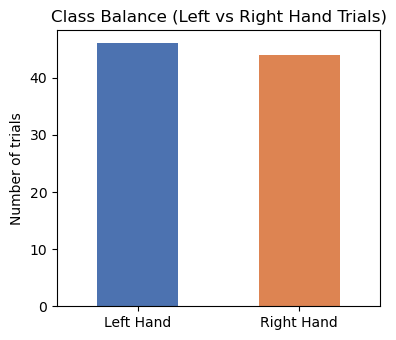

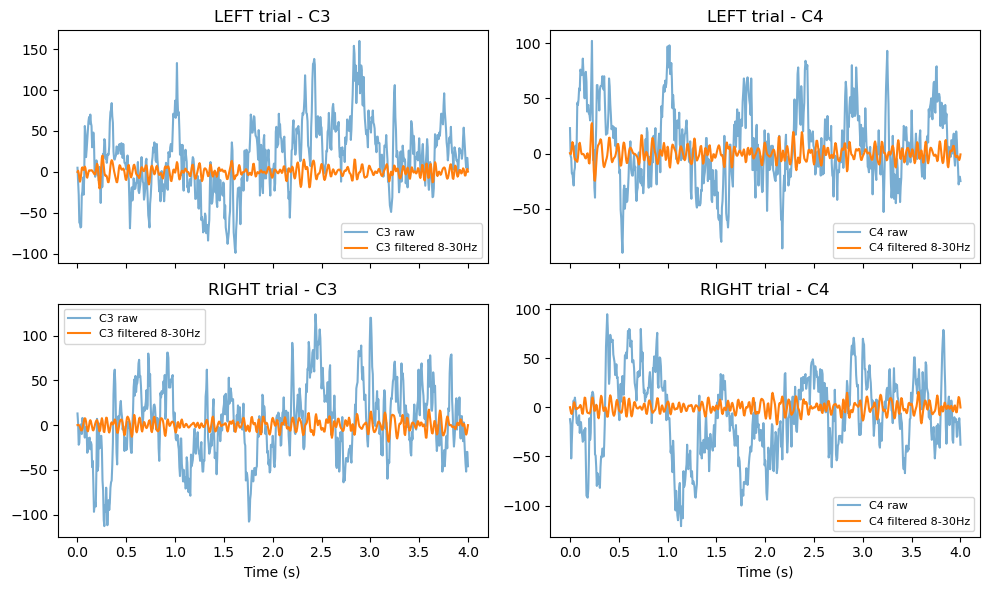

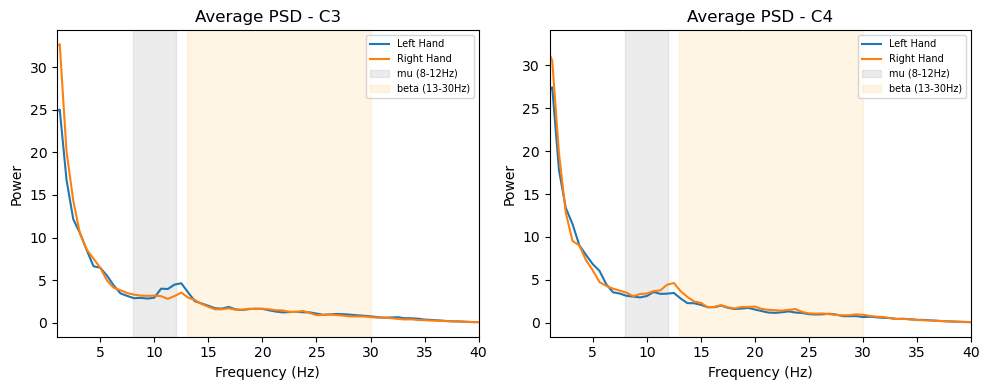

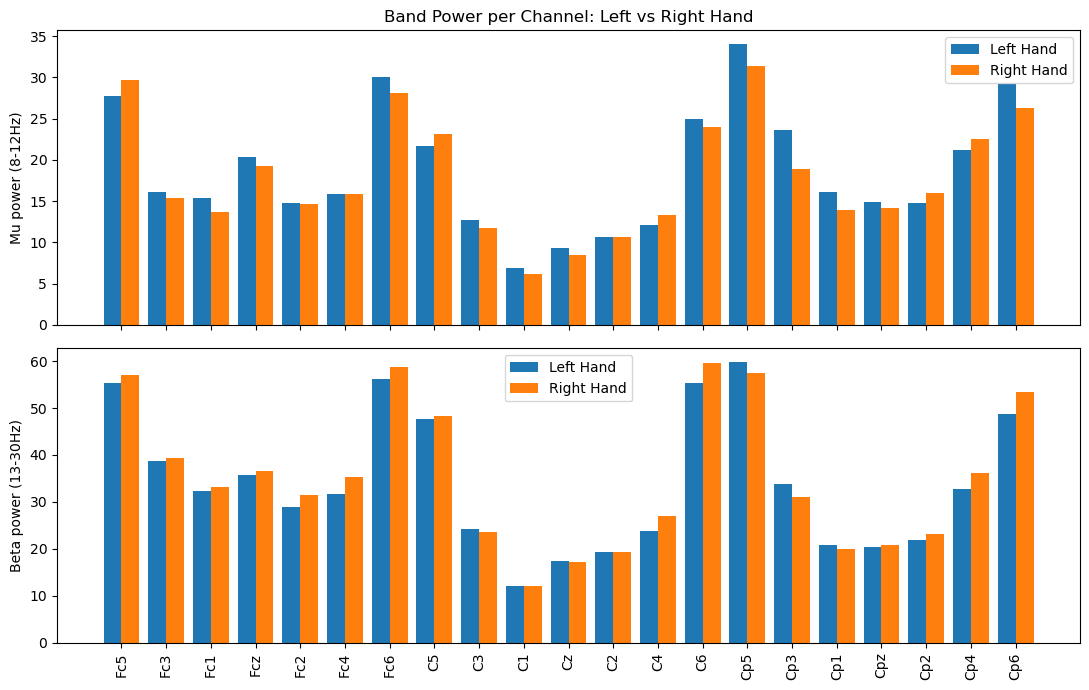

In [33]:
# ----------------------------------------------------------------------
# 3. EDA
# ----------------------------------------------------------------------
c3_idx = ch_cols.index("C3..")
c4_idx = ch_cols.index("C4..")
cz_idx = ch_cols.index("Cz..")

# 3.1 Class balance
plt.figure(figsize=(4, 3.5))
pd.Series(y_labels).value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"])
plt.title("Class Balance (Left vs Right Hand Trials)")
plt.ylabel("Number of trials")
plt.xticks(rotation=0)
plt.tight_layout()
#plt.savefig(os.path.join(OUT, "class_balance.png"), dpi=150)
#plt.close()
plt.show()
# 3.2 Time-domain example: one Left and one Right trial, C3 & C4, raw vs filtered
left_idx = np.where(y == 0)[0][0]
right_idx = np.where(y == 1)[0][0]
t = np.arange(n_times) / FS

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
for row, (idx, name) in enumerate([(left_idx, "LEFT trial"), (right_idx, "RIGHT trial")]):
    axes[row, 0].plot(t, X_raw[idx, c3_idx], label="C3 raw", alpha=0.6)
    axes[row, 0].plot(t, X_mu_beta[idx, c3_idx], label="C3 filtered 8-30Hz")
    axes[row, 0].set_title(f"{name} - C3")
    axes[row, 0].legend(fontsize=8)
    axes[row, 1].plot(t, X_raw[idx, c4_idx], label="C4 raw", alpha=0.6)
    axes[row, 1].plot(t, X_mu_beta[idx, c4_idx], label="C4 filtered 8-30Hz")
    axes[row, 1].set_title(f"{name} - C4")
    axes[row, 1].legend(fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel("Time (s)")
plt.tight_layout()
#plt.savefig(os.path.join(OUT, "time_domain_example.png"), dpi=150)
#plt.close()
plt.show()
# 3.3 PSD comparison (Welch) - Left vs Right, on C3 and C4 (using CAR broadband signal)
def avg_psd(X, ch_idx, fs=FS):
    psds = []
    for tr in range(X.shape[0]):
        f, p = welch(X[tr, ch_idx], fs=fs, nperseg=min(256, X.shape[2]))
        psds.append(p)
    return f, np.mean(psds, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, ch_idx, ch_name in [(axes[0], c3_idx, "C3"), (axes[1], c4_idx, "C4")]:
    f_l, p_l = avg_psd(X_car[y == 0], ch_idx)
    f_r, p_r = avg_psd(X_car[y == 1], ch_idx)
    ax.plot(f_l, p_l, label="Left Hand")
    ax.plot(f_r, p_r, label="Right Hand")
    ax.axvspan(8, 12, color="gray", alpha=0.15, label="mu (8-12Hz)")
    ax.axvspan(13, 30, color="orange", alpha=0.1, label="beta (13-30Hz)")
    ax.set_xlim(1, 40)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Power")
    ax.set_title(f"Average PSD - {ch_name}")
    ax.legend(fontsize=7)
plt.tight_layout()
#plt.savefig(os.path.join(OUT, "psd_comparison.png"), dpi=150)
#plt.close()
plt.show()
# 3.4 Mu/Beta band power per channel per class (bar chart, all channels)
def bandpower(X, fs, band):
    b_lo, b_hi = band
    powers = np.zeros((X.shape[0], X.shape[1]))
    for tr in range(X.shape[0]):
        for ch in range(X.shape[1]):
            f, p = welch(X[tr, ch], fs=fs, nperseg=min(256, X.shape[2]))
            mask = (f >= b_lo) & (f <= b_hi)
            powers[tr, ch] = np.trapezoid(p[mask], f[mask])
    return powers

mu_power = bandpower(X_car, FS, (8, 12))
beta_power = bandpower(X_car, FS, (13, 30))

mu_left, mu_right = mu_power[y == 0].mean(axis=0), mu_power[y == 1].mean(axis=0)
beta_left, beta_right = beta_power[y == 0].mean(axis=0), beta_power[y == 1].mean(axis=0)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
x_pos = np.arange(n_channels)
axes[0].bar(x_pos - 0.2, mu_left, width=0.4, label="Left Hand")
axes[0].bar(x_pos + 0.2, mu_right, width=0.4, label="Right Hand")
axes[0].set_ylabel("Mu power (8-12Hz)")
axes[0].legend()
axes[0].set_title("Band Power per Channel: Left vs Right Hand")

axes[1].bar(x_pos - 0.2, beta_left, width=0.4, label="Left Hand")
axes[1].bar(x_pos + 0.2, beta_right, width=0.4, label="Right Hand")
axes[1].set_ylabel("Beta power (13-30Hz)")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([c.strip('.') for c in ch_cols], rotation=90)
axes[1].legend()
plt.tight_layout()
#plt.savefig(os.path.join(OUT, "band_power_per_channel.png"), dpi=150)
#plt.close()
plt.show()
log["eda"] = {
    "c3_mu_power_left": float(mu_left[c3_idx]), "c3_mu_power_right": float(mu_right[c3_idx]),
    "c4_mu_power_left": float(mu_left[c4_idx]), "c4_mu_power_right": float(mu_right[c4_idx]),
    "c3_beta_power_left": float(beta_left[c3_idx]), "c3_beta_power_right": float(beta_right[c3_idx]),
    "c4_beta_power_left": float(beta_left[c4_idx]), "c4_beta_power_right": float(beta_right[c4_idx]),
}


In [34]:
# ----------------------------------------------------------------------
# 4 & 5. MODELING: CSP + SVM  (sklearn-compatible custom CSP transformer)
# ----------------------------------------------------------------------
class CSP(BaseEstimator, TransformerMixin):
    """Common Spatial Patterns for binary classification.
    X: (n_trials, n_channels, n_times) -> features: (n_trials, n_components)
    """
    def __init__(self, n_components=6, reg=1e-6):
        self.n_components = n_components
        self.reg = reg

    def _cov(self, trial):
        c = np.cov(trial)
        c += self.reg * np.eye(c.shape[0])
        return c / np.trace(c)

    def fit(self, X, y):
        classes = np.unique(y)
        assert len(classes) == 2, "CSP implemented for binary classification"
        cov0 = np.mean([self._cov(X[i]) for i in np.where(y == classes[0])[0]], axis=0)
        cov1 = np.mean([self._cov(X[i]) for i in np.where(y == classes[1])[0]], axis=0)
        from scipy.linalg import eigh
        eigvals, eigvecs = eigh(cov0, cov0 + cov1)
        order = np.argsort(eigvals)
        eigvecs = eigvecs[:, order]
        m = self.n_components // 2
        self.filters_ = np.concatenate([eigvecs[:, :m], eigvecs[:, -m:]], axis=1).T
        return self

    def transform(self, X):
        feats = np.zeros((X.shape[0], self.filters_.shape[0]))
        for i in range(X.shape[0]):
            projected = self.filters_ @ X[i]
            var = np.var(projected, axis=1)
            feats[i] = np.log(var / np.sum(var))
        return feats

pipe = Pipeline([
    ("csp", CSP(n_components=6)),
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)),
])

param_grid = {
    "csp__n_components": [4, 6, 8],
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", "auto"],
    "svm__kernel": ["rbf", "linear"],
}

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(pipe, param_grid, cv=inner_cv, scoring="accuracy", n_jobs=-1)

# Nested CV: outer loop gives an unbiased performance estimate,
# inner GridSearchCV (within each outer-train fold) selects hyperparameters.
y_pred = cross_val_predict(grid, X_mu_beta, y, cv=outer_cv, method="predict", n_jobs=-1)
y_proba = cross_val_predict(grid, X_mu_beta, y, cv=outer_cv, method="predict_proba", n_jobs=-1)[:, 1]

# Fold-by-fold accuracy (for reporting variance across folds)
fold_scores = []
for tr_idx, te_idx in outer_cv.split(X_mu_beta, y):
    grid.fit(X_mu_beta[tr_idx], y[tr_idx])
    fold_scores.append(grid.best_estimator_.score(X_mu_beta[te_idx], y[te_idx]))

# Fit final model on ALL data (for reference / to inspect best params) - not used for the
# reported evaluation metrics above, which come from nested cross-validation only.
grid.fit(X_mu_beta, y)
best_params = grid.best_params_

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `Cal

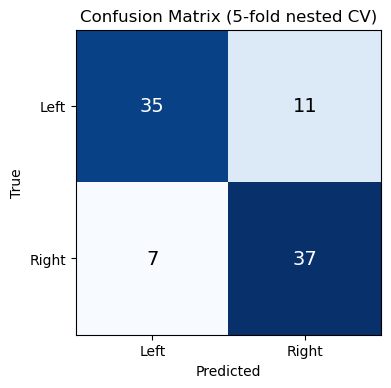

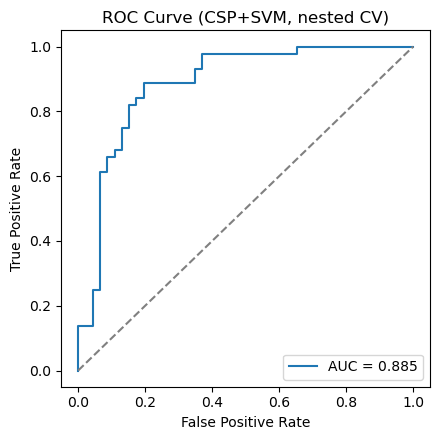

{
  "accuracy": 0.8,
  "balanced_accuracy": 0.8008893280632412,
  "f1_score": 0.8043478260869565,
  "auc": 0.8853754940711462,
  "confusion_matrix": [
    [
      35,
      11
    ],
    [
      7,
      37
    ]
  ],
  "classification_report": "              precision    recall  f1-score   support\n\n   Left Hand       0.83      0.76      0.80        46\n  Right Hand       0.77      0.84      0.80        44\n\n    accuracy                           0.80        90\n   macro avg       0.80      0.80      0.80        90\nweighted avg       0.80      0.80      0.80        90\n"
}
{
  "method": "CSP + SVM",
  "csp_band_hz": [
    8,
    30
  ],
  "best_params_full_fit": {
    "csp__n_components": 6,
    "svm__C": 1,
    "svm__gamma": "scale",
    "svm__kernel": "linear"
  },
  "outer_cv_folds": 5,
  "inner_cv_folds": 3,
  "fold_accuracies": [
    0.9444444444444444,
    0.7222222222222222,
    0.8333333333333334,
    0.7777777777777778,
    0.7222222222222222
  ],
  "fold_accuracy_mean": 0

In [35]:
# ----------------------------------------------------------------------
# 6. EVALUATION
# ----------------------------------------------------------------------
acc = accuracy_score(y, y_pred)
bal_acc = balanced_accuracy_score(y, y_pred)
f1 = f1_score(y, y_pred)
auc = roc_auc_score(y, y_proba)
cm = confusion_matrix(y, y_pred)
report_txt = classification_report(y, y_pred, target_names=["Left Hand", "Right Hand"])

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Left", "Right"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Left", "Right"])
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix (5-fold nested CV)")
plt.tight_layout()
#plt.savefig(os.path.join(OUT, "confusion_matrix.png"), dpi=150)
#plt.close()
plt.show()
fpr, tpr, _ = roc_curve(y, y_proba)
plt.figure(figsize=(4.5, 4.5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve (CSP+SVM, nested CV)")
plt.legend()
plt.tight_layout()
#plt.savefig(os.path.join(OUT, "roc_curve.png"), dpi=150)
#plt.close()
plt.show()
log["modeling"] = {
    "method": "CSP + SVM",
    "csp_band_hz": [8, 30],
    "best_params_full_fit": best_params,
    "outer_cv_folds": 5,
    "inner_cv_folds": 3,
    "fold_accuracies": [float(s) for s in fold_scores],
    "fold_accuracy_mean": float(np.mean(fold_scores)),
    "fold_accuracy_std": float(np.std(fold_scores)),
}
log["evaluation"] = {
    "accuracy": float(acc),
    "balanced_accuracy": float(bal_acc),
    "f1_score": float(f1),
    "auc": float(auc),
    "confusion_matrix": cm.tolist(),
    "classification_report": report_txt,
}

def _default(o):
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating,)):
        return float(o)
    if isinstance(o, np.ndarray):
        return o.tolist()
    raise TypeError(f"Object of type {o.__class__.__name__} is not JSON serializable")

with open(os.path.join(OUT, "results.json"), "w") as f:
    json.dump(log, f, indent=2, default=_default)

print(json.dumps(log["evaluation"], indent=2))
print(json.dumps(log["modeling"], indent=2))
print("Class counts:", log["class_counts"])
print("Artifact rejection:", log["artifact_rejection"])